In [3]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications.resnet50 import preprocess_input
import matplotlib.pyplot as plt
import numpy as np
import pickle
from pathlib import Path

In [4]:
# Get the images and labels
train_imgs = np.load('/hpcstor6/scratch01/a/anya.tongprasith001/U54REC/omama/split/train1c_imgs.npy')
train_labels = np.load('/hpcstor6/scratch01/a/anya.tongprasith001/U54REC/omama/split/train1c_labels.npy')
train_meta = np.load('/hpcstor6/scratch01/a/anya.tongprasith001/U54REC/omama/split/train1c_metadata.npy')
val_imgs = np.load('/hpcstor6/scratch01/a/anya.tongprasith001/U54REC/omama/split/val1c_imgs.npy')
val_labels = np.load('/hpcstor6/scratch01/a/anya.tongprasith001/U54REC/omama/split/val1c_labels.npy')
val_meta = np.load('/hpcstor6/scratch01/a/anya.tongprasith001/U54REC/omama/split/val1c_metadata.npy')
test_imgs = np.load('/hpcstor6/scratch01/a/anya.tongprasith001/U54REC/omama/split/test1c_imgs.npy')
test_labels = np.load('/hpcstor6/scratch01/a/anya.tongprasith001/U54REC/omama/split/test1c_labels.npy')
test_meta = np.load('/hpcstor6/scratch01/a/anya.tongprasith001/U54REC/omama/split/test1c_metadata.npy')

In [5]:
# Examine class label imbalance
neg, pos = np.bincount(train_labels.astype(int))
total = neg + pos
print('Examples:\n    Total: {}\n    Positive: {} ({:.2f}% of total)\n'.format(
    total, pos, 100 * pos / total))

Examples:
    Total: 10290
    Positive: 5145 (50.00% of total)



In [6]:
# Setup data augmentation
data_augmentation = tf.keras.Sequential([
  tf.keras.layers.RandomFlip('horizontal'),
  tf.keras.layers.RandomRotation(0.2),
])

I0000 00:00:1782745623.972129 3665437 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 38380 MB memory:  -> device: 0, name: NVIDIA A100-SXM4-40GB, pci bus id: 0000:47:00.0, compute capability: 8.0


In [7]:
# Load in the images
def load_image(path, meta, label):
    def read_npz(p, m):
        p = p.decode() # From byte to string
        img = np.load(p)['data']

        window_min = m[0]
        window_max = m[1]
        img = np.clip(img, window_min, window_max)
        img = (img - window_min) / (window_max - window_min) * 255.0
        return img.astype(np.float32)
    
    img = tf.numpy_function(read_npz, [path, meta], tf.float32)
    img = tf.expand_dims(img, axis=-1)
    img.set_shape([1024, 1024, 1])
    
    return img, label

In [8]:
# Create the dataset and group into batches
train_ds = tf.data.Dataset.from_tensor_slices((train_imgs, train_meta, train_labels))
train_ds = train_ds.shuffle(1000)
train_ds = train_ds.map(load_image, num_parallel_calls=tf.data.AUTOTUNE)
train_ds = train_ds.batch(32)

val_ds = tf.data.Dataset.from_tensor_slices((val_imgs, val_meta, val_labels))
val_ds = val_ds.map(load_image, num_parallel_calls=tf.data.AUTOTUNE)
val_ds = val_ds.batch(32)

test_ds = tf.data.Dataset.from_tensor_slices((test_imgs, test_meta, test_labels))
test_ds = test_ds.map(load_image, num_parallel_calls=tf.data.AUTOTUNE)
test_ds = test_ds.batch(32)

In [9]:
# Configure dataset performance
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.prefetch(buffer_size=AUTOTUNE)

In [10]:
# Import pretrained model
base_model = tf.keras.applications.ResNet50(input_shape=(1024, 1024, 3),
                                                  include_top=False, # Don't include ImageNet classifier at the top,
                                                  weights='imagenet',
                                                 )
# Freeze base model
base_model.trainable = False

In [11]:
base_model.summary()

Model: "resnet50"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 1024,      │          0 │ -                 │
│ (InputLayer)        │ 1024, 3)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 1030,      │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ 1030, 3)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 512, 512,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 512, 512,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 512, 512,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 514, 514,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 256, 256,  │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 256, 256,  │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 256, 256,  │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 256, 256,  │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 256, 256,  │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 256, 256,  │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 256, 256,  │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 256, 256,  │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 256, 256,  │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 256, 256,  │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 256, 256,  │      1,024 │ conv2_block1_3_c

 Total params: 23,587,712 (89.98 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 23,587,712 (89.98 MB)

In [12]:
# Image branch
# Convert image tensor from 1 channel to 3 for the model
image_input = tf.keras.Input(shape=(1024, 1024, 1), name = 'image_input')
x = data_augmentation(image_input)
x = tf.keras.layers.Concatenate()([x, x, x])
x = preprocess_input(x) 

# Keep base model in inference mode
x = base_model(x, training = False)
x = layers.GlobalAveragePooling2D()(x) # (batch, H, W, C) becomes (batch, C) — a single feature vector per image
x = layers.Dropout(0.2)(x)

outputs = layers.Dense(1, activation="sigmoid")(x)   # add activation="sigmoid" # maps feature vectors to probability score 0-1
model = tf.keras.Model(inputs = image_input, outputs = outputs) # wrap all layers

In [13]:
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ image_input         │ (None, 1024,      │          0 │ -                 │
│ (InputLayer)        │ 1024, 1)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential          │ (None, 1024,      │          0 │ image_input[0][0] │
│ (Sequential)        │ 1024, 1)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 1024,      │          0 │ sequential[0][0], │
│ (Concatenate)       │ 1024, 3)          │            │ sequential[0][0], │
│                     │                   │            │ sequential[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item (GetItem)  │ (None, 1024,      │          0 │ concatenate[0][0] │
│                     │ 1024)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_1          │ (None, 1024,      │          0 │ concatenate[0][0] │
│ (GetItem)           │ 1024)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_2          │ (None, 1024,      │          0 │ concatenate[0][0] │
│ (GetItem)           │ 1024)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack (Stack)       │ (None, 1024,      │          0 │ get_item[0][0],   │
│                     │ 1024, 3)          │            │ get_item_1[0][0], │
│                     │                   │            │ get_item_2[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 1024,      │          0 │ stack[0][0]       │
│                     │ 1024, 3)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resnet50            │ (None, 32, 32,    │ 23,587,712 │ add[0][0]         │
│ (Functional)        │ 2048)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 2048)      │          0 │ resnet50[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 2048)      │          0 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 1)         │      2,049 │ dropout[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 23,589,761 (89.99 MB)

 Trainable params: 2,049 (8.00 KB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [14]:
# Compile the model
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss=tf.keras.losses.BinaryCrossentropy(from_logits=False),
    metrics=[
        tf.keras.metrics.AUC(curve="ROC", name = 'auc'),
    ]
)

In [15]:
# Early stopping callbacks
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_auc',
        patience=3,
        restore_best_weights=True,
        mode='max'
    ),
    tf.keras.callbacks.ModelCheckpoint(
        'best_model.keras',
        monitor='val_auc',
        save_best_only=True,
        mode='max'
    )
]

In [16]:
initial_epochs = 20
history = model.fit(train_ds, 
                    epochs=initial_epochs, 
                    validation_data = val_ds, 
                    callbacks = callbacks)

Epoch 1/20


I0000 00:00:1782745639.905585 3713593 cuda_dnn.cc:461] Loaded cuDNN version 92302
Could not load symbol cuFuncGetName. Error: /usr/lib/x86_64-linux-gnu/libcuda.so.1: undefined symbol: cuFuncGetName


322/322 ━━━━━━━━━━━━━━━━━━━━ 147s 412ms/step - auc: 0.5074 - loss: 0.7655 - val_auc: 0.5531 - val_loss: 0.6825
Epoch 2/20
322/322 ━━━━━━━━━━━━━━━━━━━━ 122s 379ms/step - auc: 0.5356 - loss: 0.7320 - val_auc: 0.5862 - val_loss: 0.6736
Epoch 3/20
322/322 ━━━━━━━━━━━━━━━━━━━━ 142s 379ms/step - auc: 0.5523 - loss: 0.7125 - val_auc: 0.6096 - val_loss: 0.6673
Epoch 4/20
322/322 ━━━━━━━━━━━━━━━━━━━━ 122s 379ms/step - auc: 0.5807 - loss: 0.6927 - val_auc: 0.6284 - val_loss: 0.6632
Epoch 5/20
322/322 ━━━━━━━━━━━━━━━━━━━━ 122s 379ms/step - auc: 0.5810 - loss: 0.6900 - val_auc: 0.6446 - val_loss: 0.6572
Epoch 6/20
322/322 ━━━━━━━━━━━━━━━━━━━━ 122s 380ms/step - auc: 0.5916 - loss: 0.6809 - val_auc: 0.6549 - val_loss: 0.6536
Epoch 7/20
322/322 ━━━━━━━━━━━━━━━━━━━━ 142s 379ms/step - auc: 0.6185 - loss: 0.6693 - val_auc: 0.6660 - val_loss: 0.6498
Epoch 8/20
322/322 ━━━━━━━━━━━━━━━━━━━━ 162s 441ms/step - auc: 0.6204 - loss: 0.6667 - val_auc: 0.6740 - val_loss: 0.6482
Epoch 9/20
322/322 ━━━━━━━━━━━━━━━━

In [17]:
# See how many layers are in the base model
print("Number of layers in the base model: ", len(base_model.layers))

Number of layers in the base model:  175


In [18]:
base_model.trainable = True

# Fine-tune from this layer onwards
fine_tune_at = len(base_model.layers) - 50

# Unfreeze only the head layers
for layer in base_model.layers[:fine_tune_at]:
  layer.trainable = False

In [19]:
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ image_input         │ (None, 1024,      │          0 │ -                 │
│ (InputLayer)        │ 1024, 1)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential          │ (None, 1024,      │          0 │ image_input[0][0] │
│ (Sequential)        │ 1024, 1)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 1024,      │          0 │ sequential[0][0], │
│ (Concatenate)       │ 1024, 3)          │            │ sequential[0][0], │
│                     │                   │            │ sequential[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item (GetItem)  │ (None, 1024,      │          0 │ concatenate[0][0] │
│                     │ 1024)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_1          │ (None, 1024,      │          0 │ concatenate[0][0] │
│ (GetItem)           │ 1024)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_2          │ (None, 1024,      │          0 │ concatenate[0][0] │
│ (GetItem)           │ 1024)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack (Stack)       │ (None, 1024,      │          0 │ get_item[0][0],   │
│                     │ 1024, 3)          │            │ get_item_1[0][0], │
│                     │                   │            │ get_item_2[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 1024,      │          0 │ stack[0][0]       │
│                     │ 1024, 3)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resnet50            │ (None, 32, 32,    │ 23,587,712 │ add[0][0]         │
│ (Functional)        │ 2048)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 2048)      │          0 │ resnet50[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 2048)      │          0 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 1)         │      2,049 │ dropout[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 23,593,861 (90.00 MB)

 Trainable params: 16,952,577 (64.67 MB)

 Non-trainable params: 6,637,184 (25.32 MB)

 Optimizer params: 4,100 (16.02 KB)

In [20]:
# Compile the model
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss=tf.keras.losses.BinaryCrossentropy(from_logits=False),
    metrics=[
        tf.keras.metrics.AUC(curve="ROC", name = 'auc'),
    ],
)

In [21]:
# Train the model
fine_tune_epochs = 20
total_epochs =  initial_epochs + fine_tune_epochs
history_fine = model.fit(train_ds, 
                         epochs=total_epochs,       
                         initial_epoch=initial_epochs,  
                         validation_data=val_ds,
                         callbacks=callbacks)

Epoch 21/40
322/322 ━━━━━━━━━━━━━━━━━━━━ 217s 611ms/step - auc: 0.6996 - loss: 0.6312 - val_auc: 0.7639 - val_loss: 0.5689
Epoch 22/40
322/322 ━━━━━━━━━━━━━━━━━━━━ 242s 587ms/step - auc: 0.7700 - loss: 0.5674 - val_auc: 0.7760 - val_loss: 0.5573
Epoch 23/40
322/322 ━━━━━━━━━━━━━━━━━━━━ 182s 526ms/step - auc: 0.7874 - loss: 0.5441 - val_auc: 0.7846 - val_loss: 0.5562
Epoch 24/40
322/322 ━━━━━━━━━━━━━━━━━━━━ 221s 587ms/step - auc: 0.8007 - loss: 0.5321 - val_auc: 0.7913 - val_loss: 0.5420
Epoch 25/40
322/322 ━━━━━━━━━━━━━━━━━━━━ 182s 526ms/step - auc: 0.8084 - loss: 0.5242 - val_auc: 0.7963 - val_loss: 0.5445
Epoch 26/40
322/322 ━━━━━━━━━━━━━━━━━━━━ 202s 526ms/step - auc: 0.8237 - loss: 0.5066 - val_auc: 0.7973 - val_loss: 0.5408
Epoch 27/40
322/322 ━━━━━━━━━━━━━━━━━━━━ 220s 583ms/step - auc: 0.8309 - loss: 0.4962 - val_auc: 0.7939 - val_loss: 0.5588
Epoch 28/40
322/322 ━━━━━━━━━━━━━━━━━━━━ 189s 587ms/step - auc: 0.8369 - loss: 0.4875 - val_auc: 0.8009 - val_loss: 0.5435
Epoch 29/40
322/

In [22]:
# Evaluate model
model.evaluate(test_ds)

69/69 ━━━━━━━━━━━━━━━━━━━━ 22s 309ms/step - auc: 0.8235 - loss: 0.5037


[0.5037204623222351, 0.8235447406768799]

In [23]:
from sklearn.metrics import confusion_matrix

# Analyse confusion matrix
y_prob = model.predict(test_ds).reshape(-1)
y_pred = (y_prob >= 0.5).astype(int)
y_true = test_labels.astype(int)

cm = confusion_matrix(y_true, y_pred)

69/69 ━━━━━━━━━━━━━━━━━━━━ 25s 331ms/step


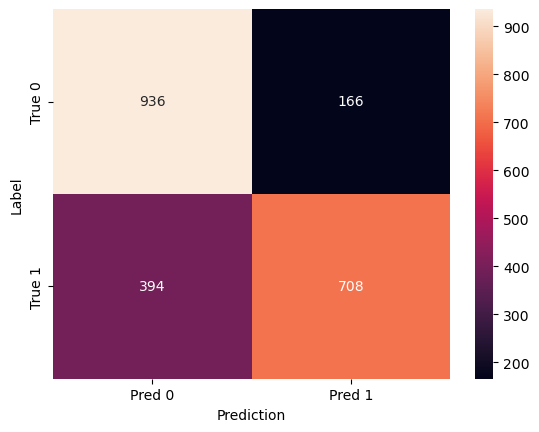

In [24]:
import seaborn as sns
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=['Pred 0', 'Pred 1'],
            yticklabels=['True 0', 'True 1'])
plt.xlabel('Prediction')
plt.ylabel('Label')
plt.show()

In [25]:
from sklearn.metrics import f1_score
f1 = f1_score(y_true, y_pred)
print(f"F1 Score: {f1:.4f}")

F1 Score: 0.7166


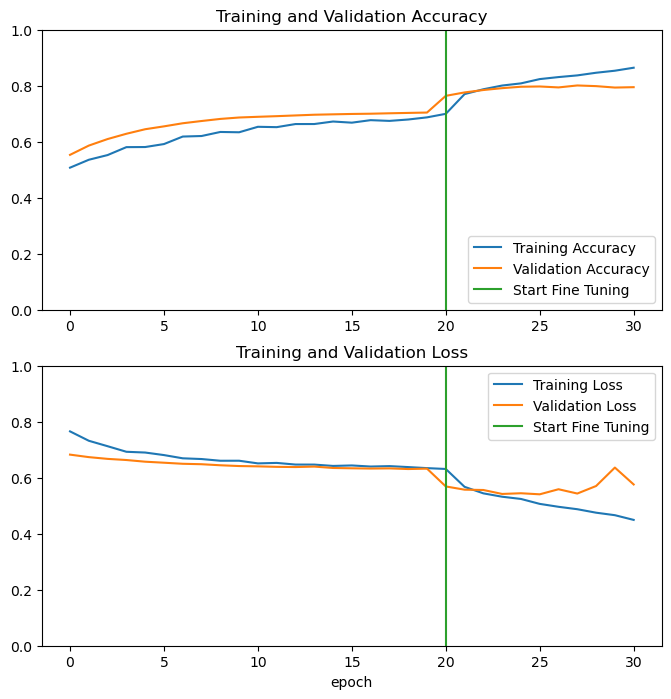

In [26]:
# Combine both for plotting
acc = history.history['auc'] + history_fine.history['auc']
val_acc = history.history['val_auc'] + history_fine.history['val_auc']
loss = history.history['loss'] + history_fine.history['loss']
val_loss = history.history['val_loss'] + history_fine.history['val_loss']

# Plot
plt.figure(figsize=(8, 8))
plt.subplot(2, 1, 1)
plt.plot(acc, label='Training Accuracy')
plt.plot(val_acc, label='Validation Accuracy')
plt.ylim([0, 1.0])
plt.plot([initial_epochs,initial_epochs],
          plt.ylim(), label='Start Fine Tuning')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(2, 1, 2)
plt.plot(loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')
plt.ylim([0, 1.0])
plt.plot([initial_epochs,initial_epochs],
         plt.ylim(), label='Start Fine Tuning')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.xlabel('epoch')
plt.show()

In [27]:
print(history.history.keys())
print(history_fine.history.keys())

dict_keys(['auc', 'loss', 'val_auc', 'val_loss'])
dict_keys(['auc', 'loss', 'val_auc', 'val_loss'])
